# Tarefa 3: Otimização de Hiperparâmetros

Aplica Grid Search e Randomized Search nos modelos da Tarefa 2 e compara o desempenho antes e depois da otimização.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

BASE_DIR = Path('..')
DATA_DIR = BASE_DIR / 'data' / 'processed'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / 'seeds_train.csv')
test = pd.read_csv(DATA_DIR / 'seeds_test.csv')

features = [c for c in train.columns if c != 'variety']
X_train, y_train = train[features], train['variety']
X_test, y_test = test[features], test['variety']

print('Treino:', X_train.shape, 'Teste:', X_test.shape)

Treino: (147, 7) Teste: (63, 7)


## Espaços de busca e otimização

In [2]:
param_grids = {
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [1000]
    }
}

base_estimators = {
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42)
}

optimized_models = {}
best_params = {}
cv_results = []

for name, estimator in base_estimators.items():
    grid = param_grids[name]
    search = GridSearchCV(estimator, grid, cv=5, scoring='accuracy', n_jobs=1)
    search.fit(X_train, y_train)
    optimized_models[name] = search.best_estimator_
    best_params[name] = search.best_params_
    cv_results.append({
        'Modelo': name,
        'Best CV Acc': search.best_score_,
        'Best Params': str(search.best_params_)
    })
    print(f'{name}: best CV acc = {search.best_score_:.4f}')

pd.DataFrame(cv_results)

KNN: best CV acc = 0.9460


SVM: best CV acc = 0.9731


Random Forest: best CV acc = 0.9462


Logistic Regression: best CV acc = 0.9662


C:\Users\João Pedro\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\João Pedro\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\João Pedro\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\João Pedro\AppData\Roaming\Pyt

,Modelo,Best CV Acc,Best Params
0,KNN,0.945977,"{'metric': 'manhattan', 'n_neighbors': 3, 'wei..."
1,SVM,0.973103,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}"
2,Random Forest,0.946207,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
3,Logistic Regression,0.966207,"{'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}"


## Melhores hiperparâmetros

In [3]:
for name, params in best_params.items():
    print(f'\n{name}:')
    for k, v in params.items():
        print(f'  {k}: {v}')


KNN:
  metric: manhattan
  n_neighbors: 3
  weights: uniform

SVM:
  C: 1
  gamma: scale
  kernel: linear

Random Forest:
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 10
  n_estimators: 200

Logistic Regression:
  C: 10
  max_iter: 1000
  solver: lbfgs


## Avaliação no conjunto de teste

In [4]:
optimized_results = []
for name, model in optimized_models.items():
    y_pred = model.predict(X_test)
    optimized_results.append({
        'Modelo': name,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

optimized_df = pd.DataFrame(optimized_results).sort_values('Acurácia', ascending=False)
optimized_df.round(4)

,Modelo,Acurácia,Precisão,Recall,F1-score
0,KNN,0.9048,0.9069,0.9048,0.9055
1,SVM,0.8889,0.8887,0.8889,0.8885
3,Logistic Regression,0.8889,0.8887,0.8889,0.8885
2,Random Forest,0.8413,0.8415,0.8413,0.8402


## Comparação: base vs otimizado

In [5]:
base_results = {
    'KNN': 0.8889,
    'SVM': 0.8889,
    'Random Forest': 0.8413,
    'Logistic Regression': 0.9048
}

comparison = optimized_df.copy()
comparison['Acurácia Base'] = comparison['Modelo'].map(base_results)
comparison['Delta'] = comparison['Acurácia'] - comparison['Acurácia Base']
comparison = comparison[['Modelo', 'Acurácia Base', 'Acurácia', 'Delta']]
comparison.round(4)

,Modelo,Acurácia Base,Acurácia,Delta
0,KNN,0.8889,0.9048,0.0159
1,SVM,0.8889,0.8889,-0.0000
3,Logistic Regression,0.9048,0.8889,-0.0159
2,Random Forest,0.8413,0.8413,-0.0000


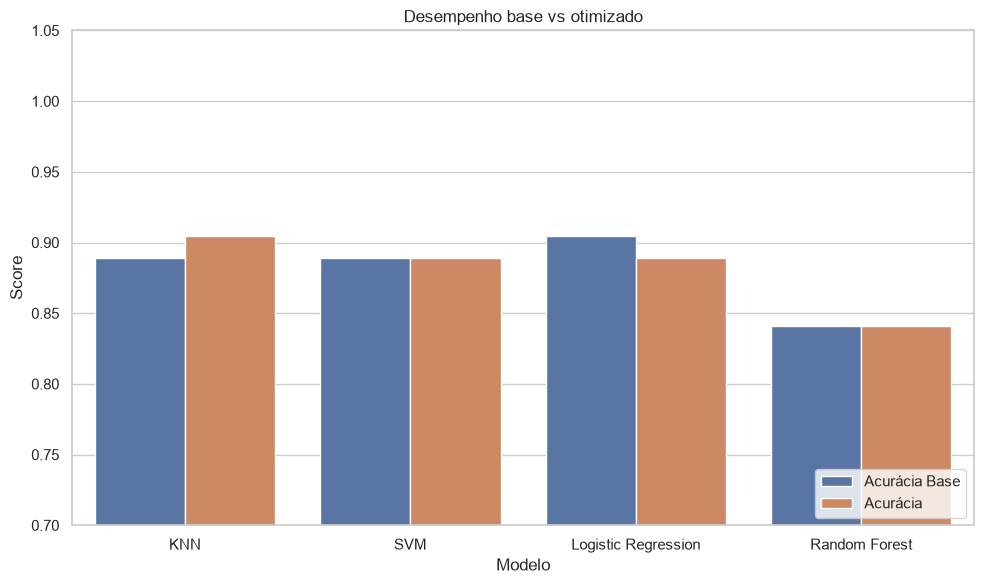

In [6]:
comparison_plot = comparison.melt(id_vars='Modelo', value_vars=['Acurácia Base', 'Acurácia'],
                                  var_name='Versão', value_name='Score')
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_plot, x='Modelo', y='Score', hue='Versão')
plt.ylim(0.7, 1.05)
plt.title('Desempenho base vs otimizado')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Matrizes de confusão dos modelos otimizados

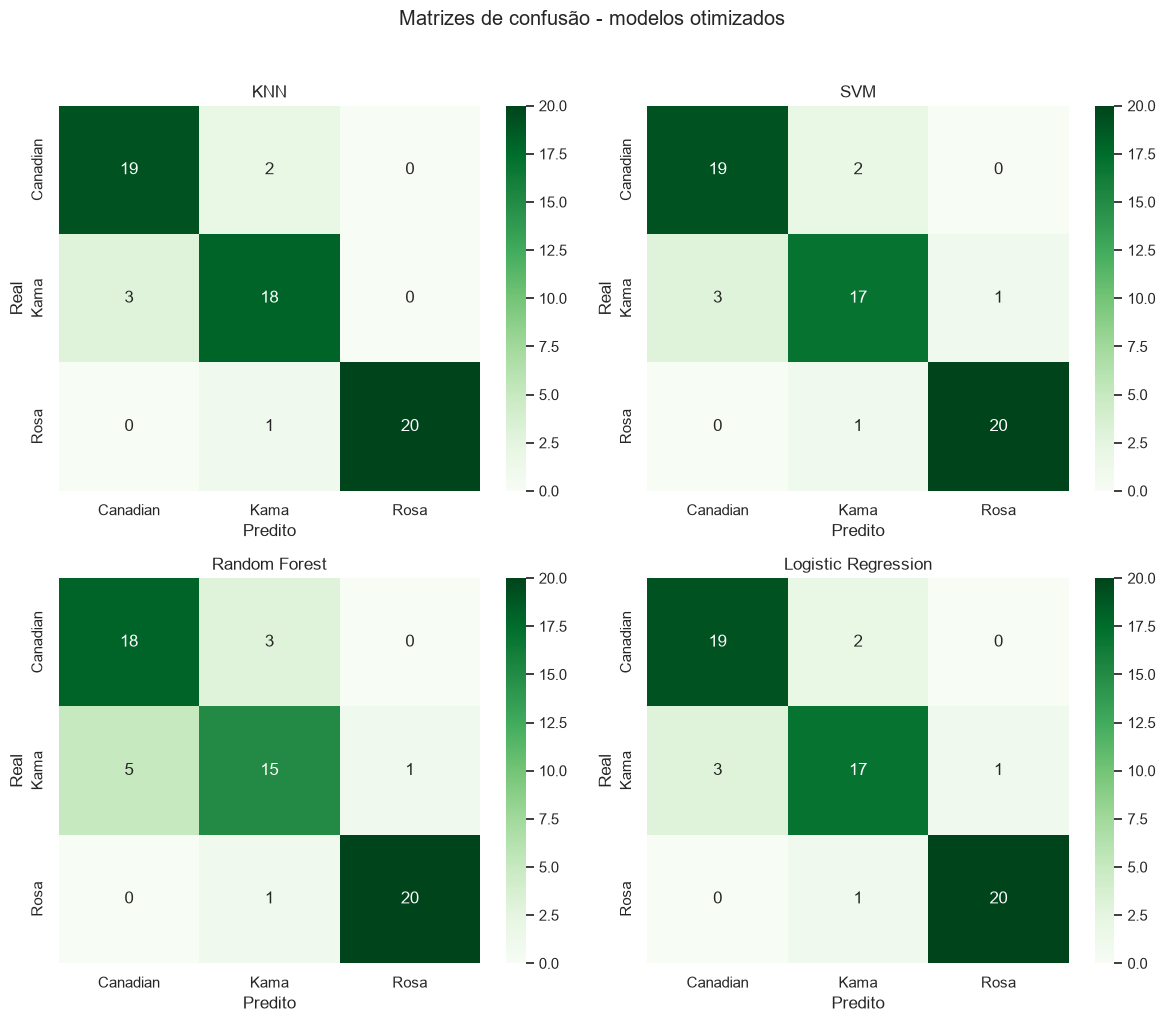

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
classes = sorted(y_test.unique())

for idx, (name, model) in enumerate(optimized_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=classes, yticklabels=classes, ax=axes[idx])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predito')
    axes[idx].set_ylabel('Real')

plt.suptitle('Matrizes de confusão - modelos otimizados', y=1.02)
plt.tight_layout()
plt.show()

## Salvar modelos otimizados

In [8]:
for name, model in optimized_models.items():
    safe_name = name.lower().replace(' ', '_')
    joblib.dump(model, MODELS_DIR / f'{safe_name}_optimized.pkl')

print('Modelos otimizados salvos em', MODELS_DIR)

Modelos otimizados salvos em ..\models
